#Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Set plotting style for better notebook visualization
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['font.size'] = 10

#Define Jansen-Rit Model with Seed Control

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

class JansenRitModel:
    def __init__(self, dt=0.001, T=10.0, seed=42):
        self.dt = dt          # Time step (1 ms)
        self.T = T            # Total simulation time in seconds
        self.N = int(T / dt)  # Total number of time steps
        self.seed = seed      # Added to ensure reproducible noise

        # Standard biological parameters from Jansen & Rit (1995)
        self.A = 3.25         # Excitatory gain (mV)
        self.B = 22.0         # Inhibitory gain (mV)
        self.a = 100.0        # Excitatory time constant (1/s)
        self.b = 50.0         # Inhibitory time constant (1/s)

        # Connectivity constants between neural populations
        self.C = 135.0
        self.C1 = self.C
        self.C2 = 0.8 * self.C
        self.C3 = 0.25 * self.C
        self.C4 = 0.25 * self.C

        # Sigmoid function parameters
        self.v0 = 6.0         # Firing threshold (mV)
        self.e0 = 2.5         # Half of maximum firing rate (1/s)
        self.r = 0.56         # Sigmoid slope (1/mV)

    def sigmoid(self, v):
        """Transform membrane potential into average firing rate."""
        return (2 * self.e0) / (1 + np.exp(self.r * (self.v0 - v)))

    def simulate(self, p_mean=220.0, p_std=10.0):
        # Set the random seed right before simulation starts
        np.random.seed(self.seed)

        """
        Simulate the model using Euler-Maruyama stochastic integration.
        p_mean: Mean background input
        p_std: Standard deviation of environmental white noise
        """
        # State matrix: 6 state variables x N time steps
        y = np.zeros((6, self.N))
        t = np.arange(0, self.T, self.dt)

        # Main differential equation solving loop
        for i in range(1, self.N):
            # Generate stochastic white noise input
            noise = np.random.normal(0, 1)
            p_t = p_mean + p_std * noise / np.sqrt(self.dt)

            # Calculate derivatives (State-Space Equations)
            dy0 = y[3, i-1]
            dy3 = self.A * self.a * self.sigmoid(y[1, i-1] - y[2, i-1]) - 2 * self.a * y[3, i-1] - (self.a**2) * y[0, i-1]

            dy1 = y[4, i-1]
            dy4 = self.A * self.a * (p_t + self.C2 * self.sigmoid(self.C1 * y[0, i-1])) - 2 * self.a * y[4, i-1] - (self.a**2) * y[1, i-1]

            dy2 = y[5, i-1]
            dy5 = self.B * self.b * (self.C4 * self.sigmoid(self.C3 * y[0, i-1])) - 2 * self.b * y[5, i-1] - (self.b**2) * y[2, i-1]

            # Update states using Euler-Maruyama integration step
            y[0, i] = y[0, i-1] + dy0 * self.dt
            y[3, i] = y[3, i-1] + dy3 * self.dt
            y[1, i] = y[1, i-1] + dy1 * self.dt
            y[4, i] = y[4, i-1] + dy4 * self.dt
            y[2, i] = y[2, i-1] + dy2 * self.dt
            y[5, i] = y[5, i-1] + dy5 * self.dt

        # Output EEG is the post-synaptic potential of pyramidal cells (y1 - y2)
        eeg = y[1, :] - y[2, :]
        return t, eeg

#Simulation & Plotting

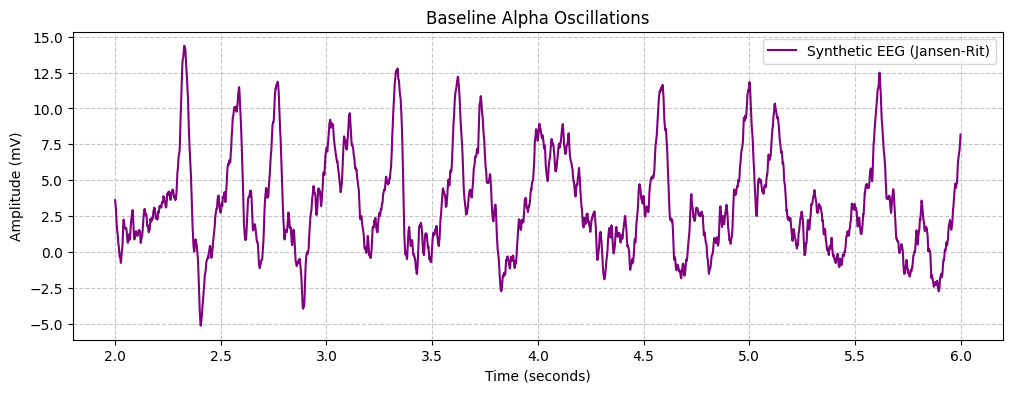

In [ ]:
# Initialize the model for 6 seconds of data
model = JansenRitModel(dt=0.001, T=6.0)
t, eeg = model.simulate(p_mean=120.0, p_std=10.0)

# Remove the first 2 seconds to filter out the transient startup dynamics
stable_idx = t >= 2.0

# Plot the steady-state synthetic EEG signal
plt.figure()
plt.plot(t[stable_idx], eeg[stable_idx], color='purple', linewidth=1.5, label='Synthetic EEG (Jansen-Rit)')
plt.title('Baseline Alpha Oscillations')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (mV)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

#Weak & Strong Alpha Regime

In [ ]:
from scipy.signal import welch
# Use the model built in this session before (assumes JansenRitModel class is already run)
model = JansenRitModel(dt=0.001, T=8.0)

# Simulate Weak Alpha Regime (Low baseline input)
t_weak, eeg_weak = model.simulate(p_mean=90.0, p_std=10.0)

# Simulate Strong Alpha Regime (High baseline input - Classic Alpha)
t_strong, eeg_strong = model.simulate(p_mean=220.0, p_std=10.0)

# Filter out the first 2 seconds of transient dynamics for both signals
stable_mask = t_weak >= 2.0
t_stable = t_weak[stable_mask]
eeg_weak_stable = eeg_weak[stable_mask]
eeg_strong_stable = eeg_strong[stable_mask]

#PSD Calculation

In [ ]:
# Sampling frequency is 1 / dt = 1000 Hz
fs = 1000

# Compute PSD using Welch's method for both regimes
freqs_weak, psd_weak = welch(eeg_weak_stable, fs=fs, nperseg=1024)
freqs_strong, psd_strong = welch(eeg_strong_stable, fs=fs, nperseg=1024)

# Bifurcation Plot

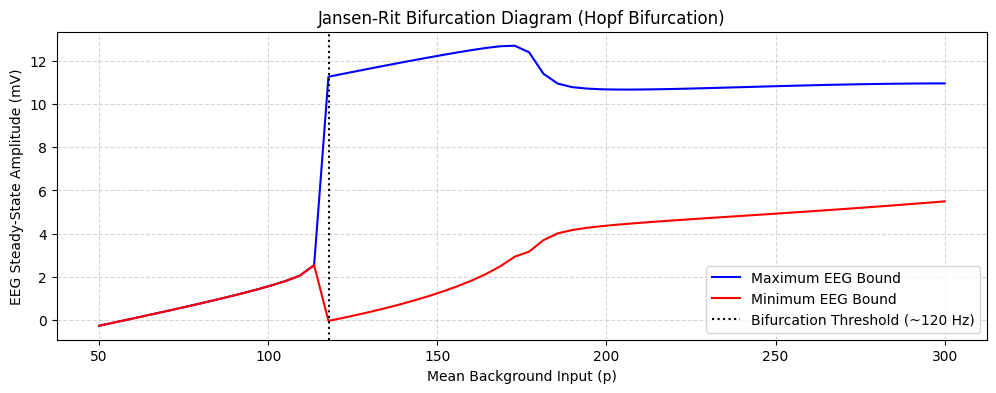

In [ ]:
# Create a range of input values (p_mean) to sweep
p_range = np.linspace(50, 300, 60)

max_values = []
min_values = []

# Sweep through each input value deterministically (no noise)
for p in p_range:
    # Use the class with 4 seconds of simulation
    model_sweep = JansenRitModel(dt=0.001, T=4.0)

    # Set p_std=0.0 to observe pure deterministic bifurcation
    t_s, eeg_s = model_sweep.simulate(p_mean=p, p_std=0.0)

    # Discard transient dynamics (first 2 seconds) to get steady state
    stable_eeg = eeg_s[t_s >= 2.0]

    # Extract the local maximum and minimum of the steady-state signal
    max_values.append(np.max(stable_eeg))
    min_values.append(np.min(stable_eeg))

# Plotting the Bifurcation Diagram
plt.figure()
plt.plot(p_range, max_values, color='blue', label='Maximum EEG Bound')
plt.plot(p_range, min_values, color='red', label='Minimum EEG Bound')
plt.axvline(x=118, color='black', linestyle=':', label='Bifurcation Threshold (~120 Hz)')
plt.title('Jansen-Rit Bifurcation Diagram (Hopf Bifurcation)')
plt.xlabel('Mean Background Input (p)')
plt.ylabel('EEG Steady-State Amplitude (mV)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# Plot Baseline Regimes

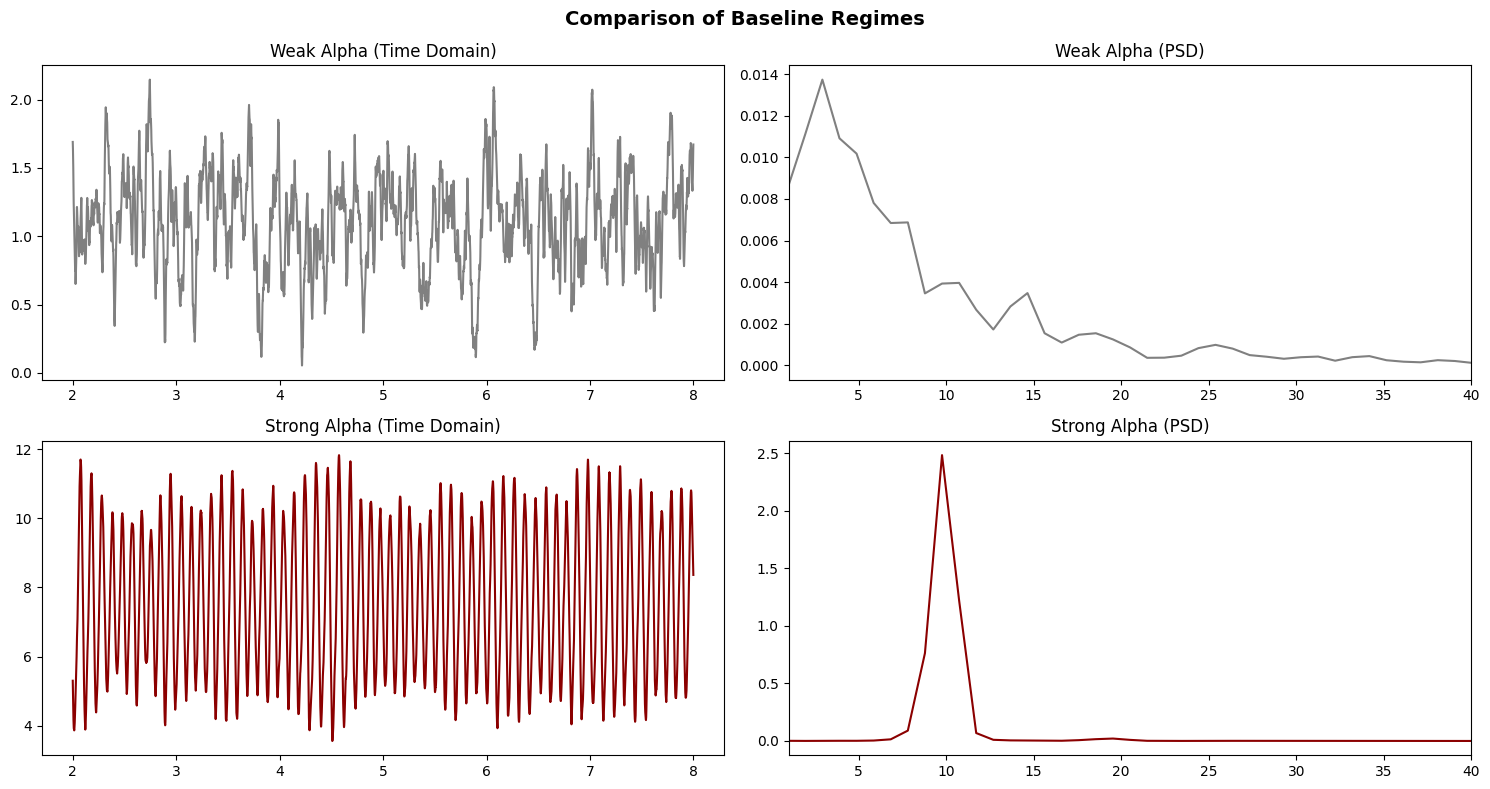

In [ ]:
# Initialize model with a fixed seed
model_rep = JansenRitModel(dt=0.001, T=8.0, seed=42)

# Run standard regimes (90 for Weak, 140 for Strong based on your bifurcation plot)
t_weak, eeg_weak = model_rep.simulate(p_mean=90.0, p_std=2.0)
t_strong, eeg_strong = model_rep.simulate(p_mean=220.0, p_std=2.0)

stable_mask = t_weak >= 2.0
t_stable = t_weak[stable_mask]
eeg_weak_stable = eeg_weak[stable_mask]
eeg_strong_stable = eeg_strong[stable_mask]

fs = 1000
freqs_weak, psd_weak = welch(eeg_weak_stable, fs=fs, nperseg=1024)
freqs_strong, psd_strong = welch(eeg_strong_stable, fs=fs, nperseg=1024)

# Plotting code remains identical but results are locked
fig, axs = plt.subplots(2, 2, figsize=(15, 8))
fig.suptitle('Comparison of Baseline Regimes', fontsize=14, fontweight='bold')

axs[0, 0].plot(t_stable, eeg_weak_stable, color='gray')
axs[0, 0].set_title('Weak Alpha (Time Domain)')
axs[0, 1].plot(freqs_weak, psd_weak, color='gray')
axs[0, 1].set_title('Weak Alpha (PSD)')
axs[0, 1].set_xlim([1, 40])

axs[1, 0].plot(t_stable, eeg_strong_stable, color='darkred')
axs[1, 0].set_title('Strong Alpha (Time Domain)')
axs[1, 1].plot(freqs_strong, psd_strong, color='darkred')
axs[1, 1].set_title('Strong Alpha (PSD)')
axs[1, 1].set_xlim([1, 40])

plt.tight_layout()
plt.show()

# Jansen-Rit Class with TMS Module

In [ ]:
class JansenRitStandard:
    def __init__(self, dt=0.001, T=8.0, seed=42):
        self.dt = dt
        self.T = T
        self.N = int(T / dt)
        self.seed = seed

        # Authentic Classic 1995 Parameters
        self.A = 3.25
        self.B = 22.0
        self.a = 100.0
        self.b = 50.0

        self.C = 135.0
        self.C1 = self.C
        self.C2 = 0.8 * self.C
        self.C3 = 0.25 * self.C
        self.C4 = 0.25 * self.C

        self.v0 = 6.0
        self.e0 = 2.5
        self.r = 0.56

    def sigmoid(self, v):
        return (2 * self.e0) / (1 + np.exp(self.r * (self.v0 - v)))

    def simulate(self, p_mean=220.0, p_std=2.0, tms_amp=0.0, tms_time=4.0, tms_sigma=0.001):
        """
        Simulates the Jansen-Rit model with optional Gaussian TMS perturbation.
        """
        np.random.seed(self.seed)
        y = np.zeros((6, self.N))
        t = np.arange(0, self.T, self.dt)

        for i in range(1, self.N):
            # 1. Background White Noise
            noise = np.random.normal(0, 1)
            p_noise = p_std * noise / np.sqrt(self.dt)

            # 2. Transient TMS Pulse Formulation
            p_tms = tms_amp * np.exp(-((t[i-1] - tms_time)**2) / (2 * (tms_sigma**2)))

            # Total Excitatory Input
            p_t = p_mean + p_noise + p_tms

            # Differential Equations (Euler-Maruyama Step)
            dy0 = y[3, i-1]
            dy3 = self.A * self.a * self.sigmoid(y[1, i-1] - y[2, i-1]) - 2 * self.a * y[3, i-1] - (self.a**2) * y[0, i-1]

            dy1 = y[4, i-1]
            dy4 = self.A * self.a * (p_t + self.C2 * self.sigmoid(self.C1 * y[0, i-1])) - 2 * self.a * y[4, i-1] - (self.a**2) * y[1, i-1]

            dy2 = y[5, i-1]
            dy5 = self.B * self.b * (self.C4 * self.sigmoid(self.C3 * y[0, i-1])) - 2 * self.b * y[5, i-1] - (self.b**2) * y[2, i-1]

            y[0, i] = y[0, i-1] + dy0 * self.dt
            y[3, i] = y[3, i-1] + dy3 * self.dt
            y[1, i] = y[1, i-1] + dy1 * self.dt
            y[4, i] = y[4, i-1] + dy4 * self.dt
            y[2, i] = y[2, i-1] + dy2 * self.dt
            y[5, i] = y[5, i-1] + dy5 * self.dt

        return t, (y[1, :] - y[2, :])

# Simulating and Comparing TMS Effects on Baseline Regimes

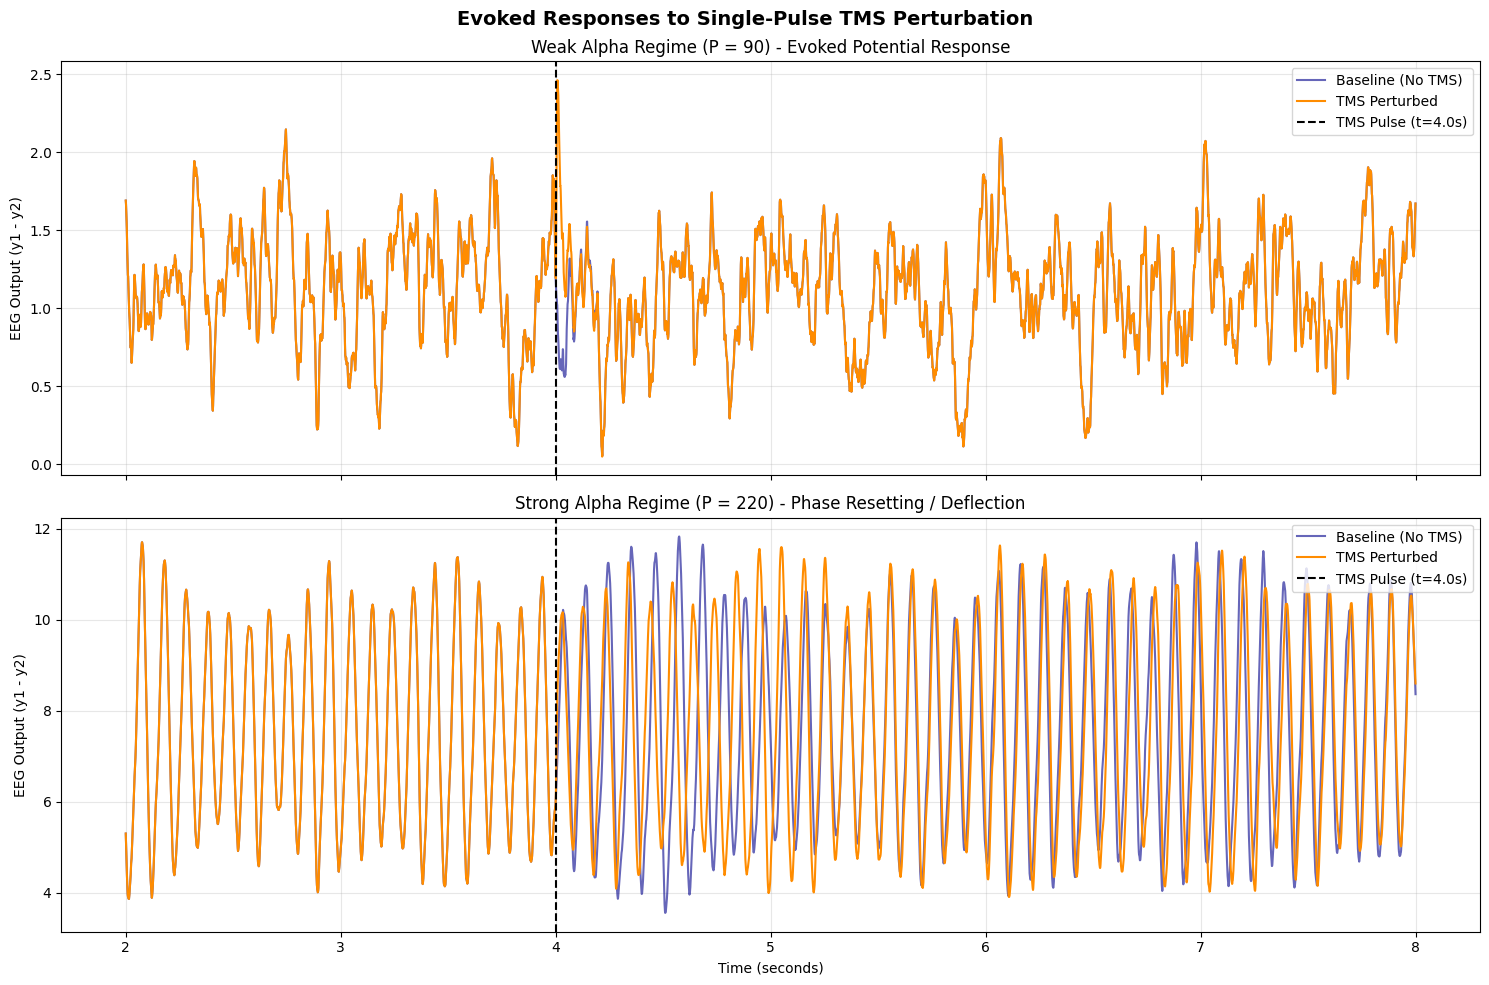

In [ ]:
model = JansenRitStandard(dt=0.001, T=8.0, seed=42)
TMS_TIME = 4.0

# 1. Simulation on Weak Alpha Regime (P = 90)
t, eeg_weak_base = model.simulate(p_mean=90.0, p_std=2.0, tms_amp=0.0)
_, eeg_weak_tms  = model.simulate(p_mean=90.0, p_std=2.0, tms_amp=500.0, tms_time=TMS_TIME)

# 2. Simulation on Strong Alpha Regime (P = 220)
_, eeg_strong_base = model.simulate(p_mean=220.0, p_std=2.0, tms_amp=0.0)
_, eeg_strong_tms  = model.simulate(p_mean=220.0, p_std=2.0, tms_amp=500.0, tms_time=TMS_TIME)

# Filter out transient state for clean plotting (Keep t >= 2.0)
mask = t >= 2.0
t_plot = t[mask]

# 3. Plotting the Perturbation Results
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)
fig.suptitle('Evoked Responses to Single-Pulse TMS Perturbation', fontsize=14, fontweight='bold')

# Plot Weak Alpha Response
axs[0].plot(t_plot, eeg_weak_base[mask], label='Baseline (No TMS)', color='darkblue', alpha=0.6)
axs[0].plot(t_plot, eeg_weak_tms[mask], label='TMS Perturbed', color='darkorange', linewidth=1.5)
axs[0].axvline(x=TMS_TIME, color='black', linestyle='--', label='TMS Pulse (t=4.0s)')
axs[0].set_title('Weak Alpha Regime (P = 90) - Evoked Potential Response')
axs[0].set_ylabel('EEG Output (y1 - y2)')
axs[0].legend(loc='upper right')
axs[0].grid(True, alpha=0.3)

# Plot Strong Alpha Response
axs[1].plot(t_plot, eeg_strong_base[mask], label='Baseline (No TMS)', color='darkblue', alpha=0.6)
axs[1].plot(t_plot, eeg_strong_tms[mask], label='TMS Perturbed', color='darkorange', linewidth=1.5)
axs[1].axvline(x=TMS_TIME, color='black', linestyle='--', label='TMS Pulse (t=4.0s)')
axs[1].set_title('Strong Alpha Regime (P = 220) - Phase Resetting / Deflection')
axs[1].set_xlabel('Time (seconds)')
axs[1].set_ylabel('EEG Output (y1 - y2)')
axs[1].legend(loc='upper right')
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()